# Import data

In [2]:
import pandas as pd

from analyze_src.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy, UniqueValuesInspectionStrategy
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis 
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis

# Load Data

In [3]:
file_id = "1YGB0V3H-2o3-2__8PA3XNOLWpqXEqgI6"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


# Step 1: Basic Data Inspection

## info()

In [4]:
data_inspector = DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df)


 Data Types & Non-null Counts: 

<class 'pandas.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   str    
dtypes: float64(14), str(1)
memory usage: 150.2 KB


## describe()

In [5]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df)


 Summary Statistics (Numerical Features): 

               WBC         LYMp        NEUTp         LYMn        NEUTn  \
count  1281.000000  1281.000000  1281.000000  1281.000000  1281.000000   
mean      7.862717    25.845000    77.511000     1.880760     5.140940   
std       3.564466     7.038728   147.746273     1.335689     2.872294   
min       0.800000     6.200000     0.700000     0.200000     0.500000   
25%       6.000000    25.845000    71.100000     1.880760     5.100000   
50%       7.400000    25.845000    77.511000     1.880760     5.140940   
75%       8.680000    25.845000    77.511000     1.880760     5.140940   
max      45.700000    91.400000  5317.000000    41.800000    79.000000   

               RBC          HGB        HCT          MCV          MCH  \
count  1281.000000  1281.000000  1281.0000  1281.000000  1281.000000   
mean      4.708267    12.184551    46.1526    85.793919    32.084840   
std       2.817200     3.812897   104.8861    27.177663   111.170756   


## Unique

In [6]:
data_inspector.set_strategy(UniqueValuesInspectionStrategy())
data_inspector.execute_inspection(df)


 Unique Values and Counts for Categorical Features: 


 Column: Diagnosis
<StringArray>
[ 'Normocytic hypochromic anemia',         'Iron deficiency anemia',
        'Other microcytic anemia',                       'Leukemia',
                        'Healthy',               'Thrombocytopenia',
 'Normocytic normochromic anemia', 'Leukemia with thrombocytopenia',
              'Macrocytic anemia']
Length: 9, dtype: str
Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64


In [7]:
# (Leukemia with thrombocytopenia - Macrocytic anemia - Leukemia - Other microcytic anemia - Thrombocytopenia) = others
# two models the first (Healthy - Normocytic hypochromic anemia - Normocytic normochromic anemia - Iron deficiency anemia - others) and the second between others

# Step 2: Missing Values Analysis


Missing Value Count by Column: 
Series([], dtype: int64)

Visualizing MIssing Values...


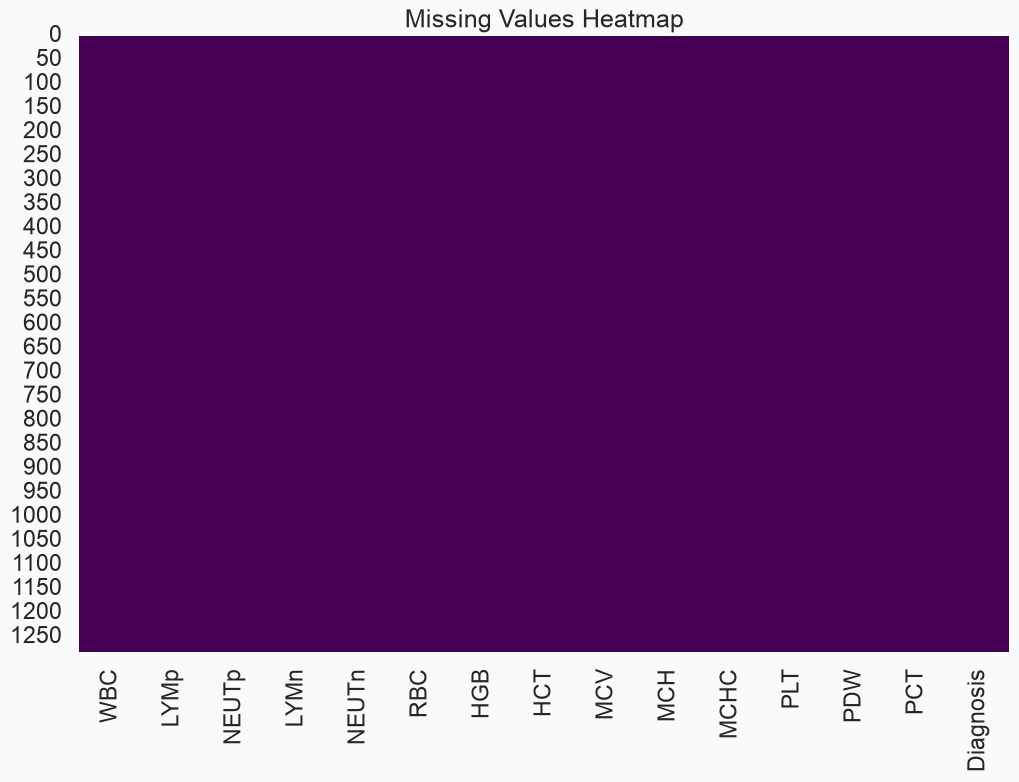

In [8]:
missing_value_analysis= SimpleMissingValuesAnalysis()
missing_value_analysis.analyze(df)

# Step 3: Univariate Analysis

## Numerical

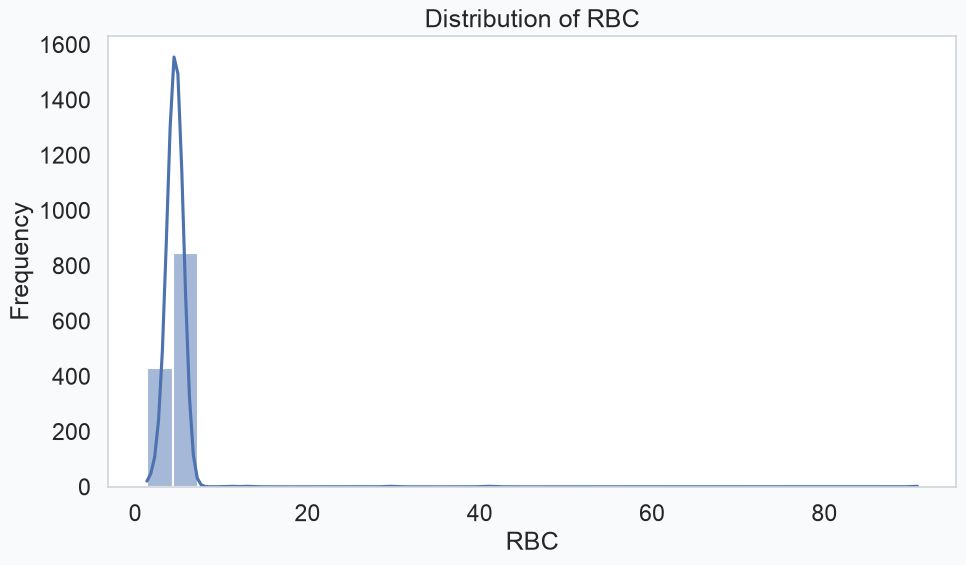

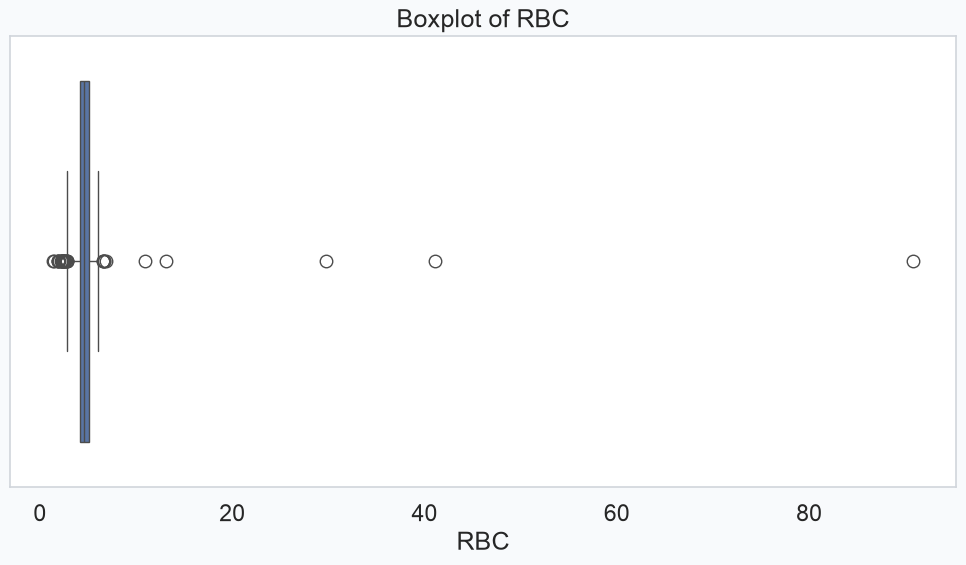

In [9]:
univariate_analysis= UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analysis.execute_analysis(df, 'RBC')

## Categorical

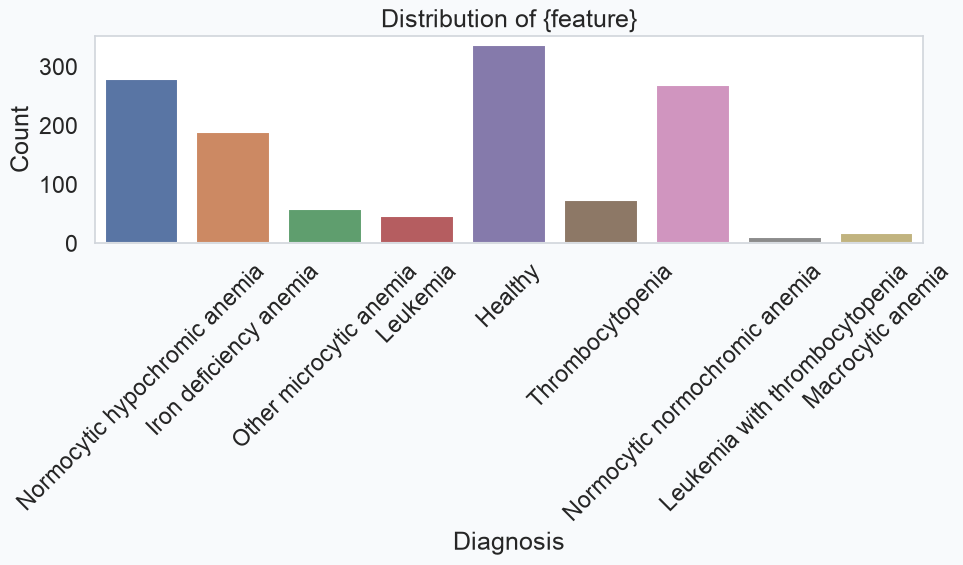

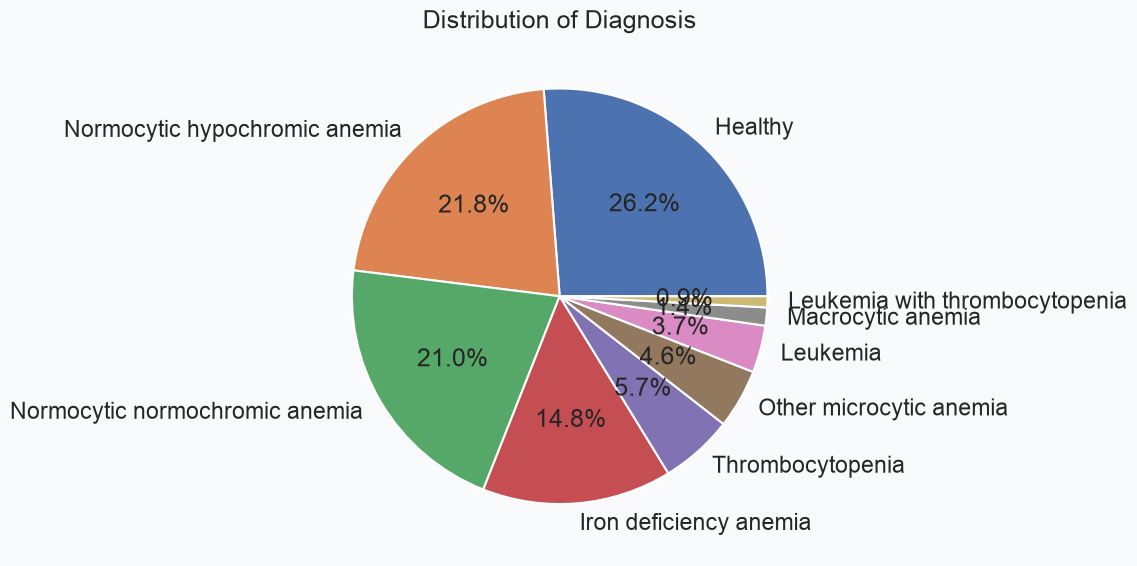

In [10]:
univariate_analysis.set_strategy(CategoricalUnivariateAnalysis())
univariate_analysis.execute_analysis(df, 'Diagnosis')

# Step 4: Bivariate Analysis

## Numerical VS Numerical

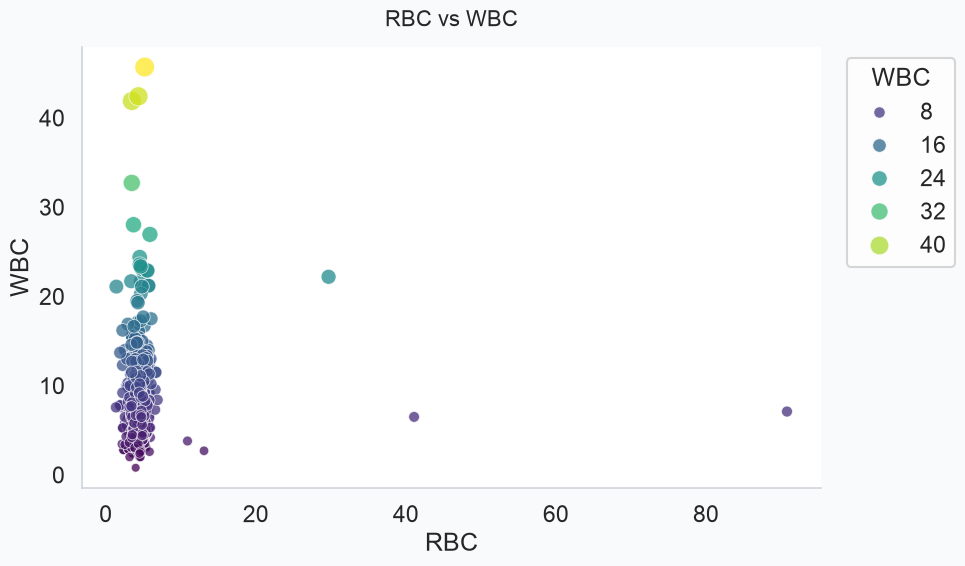

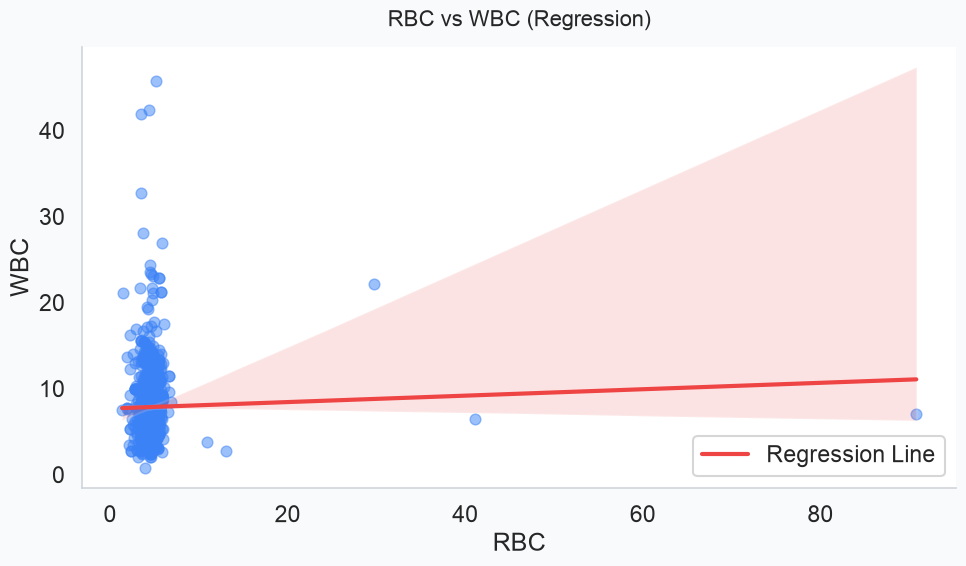

In [11]:
bivariate_analysis= BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analysis.execute_analysis(df, 'RBC', 'WBC')

## Categorical VS Numerical

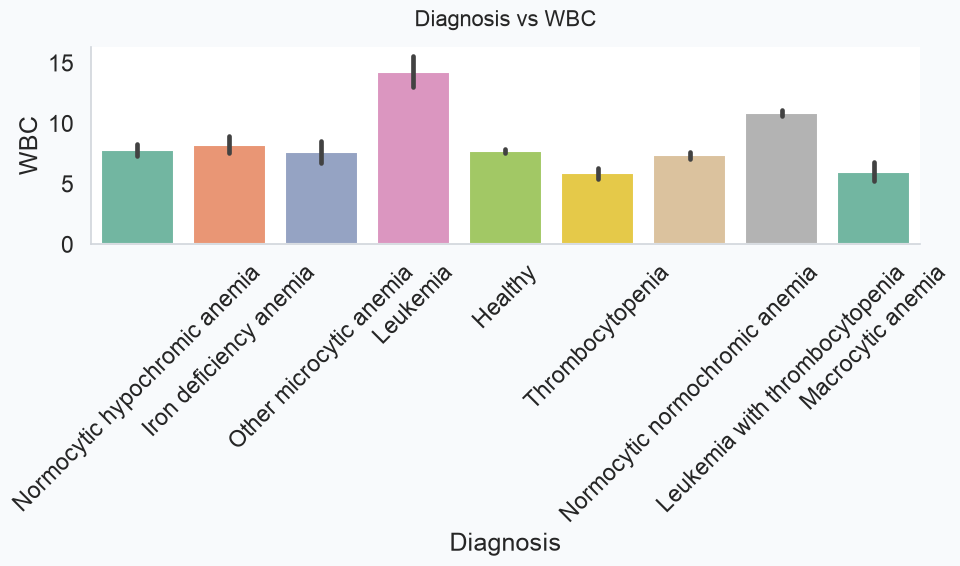

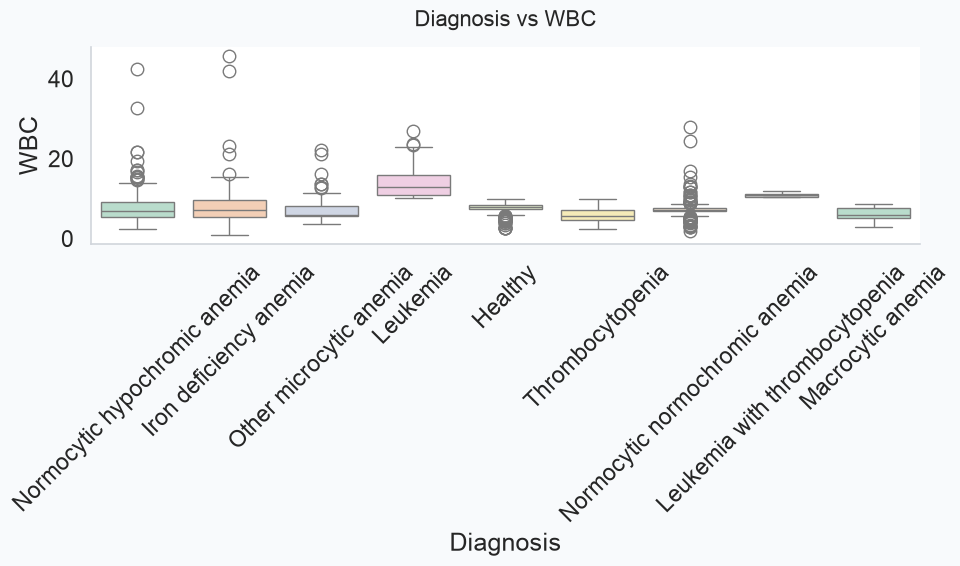

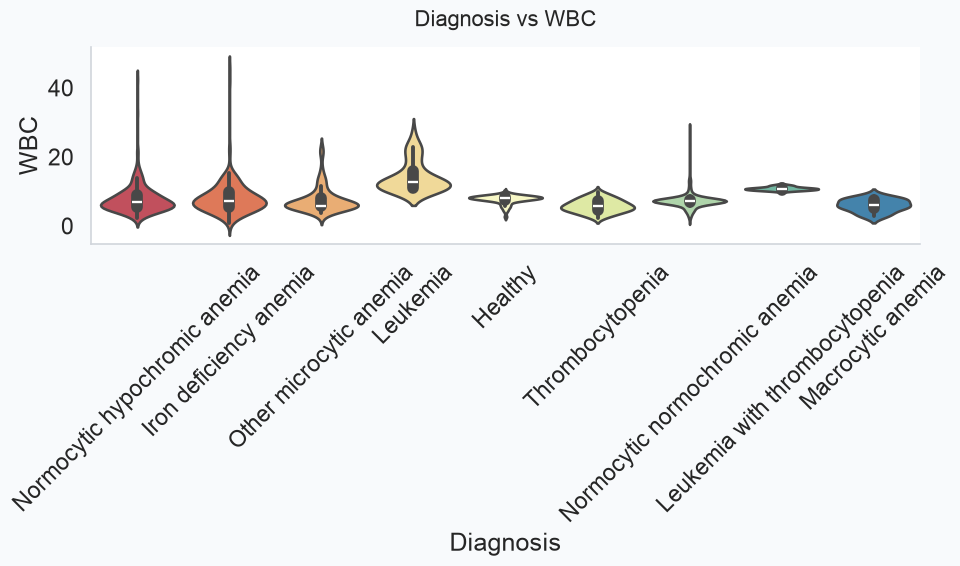

In [12]:
bivariate_analysis.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analysis.execute_analysis(df, "Diagnosis", "WBC")

# Multivariate Analysis

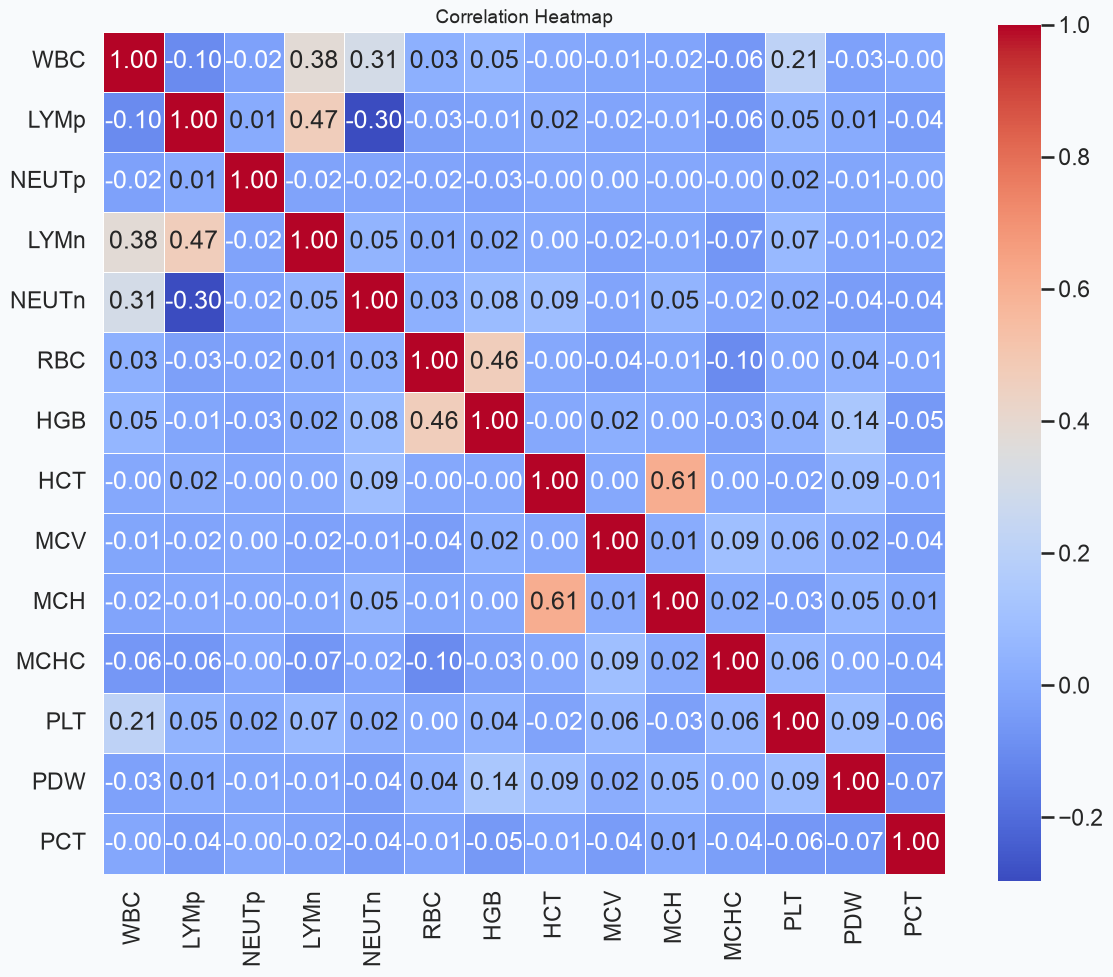

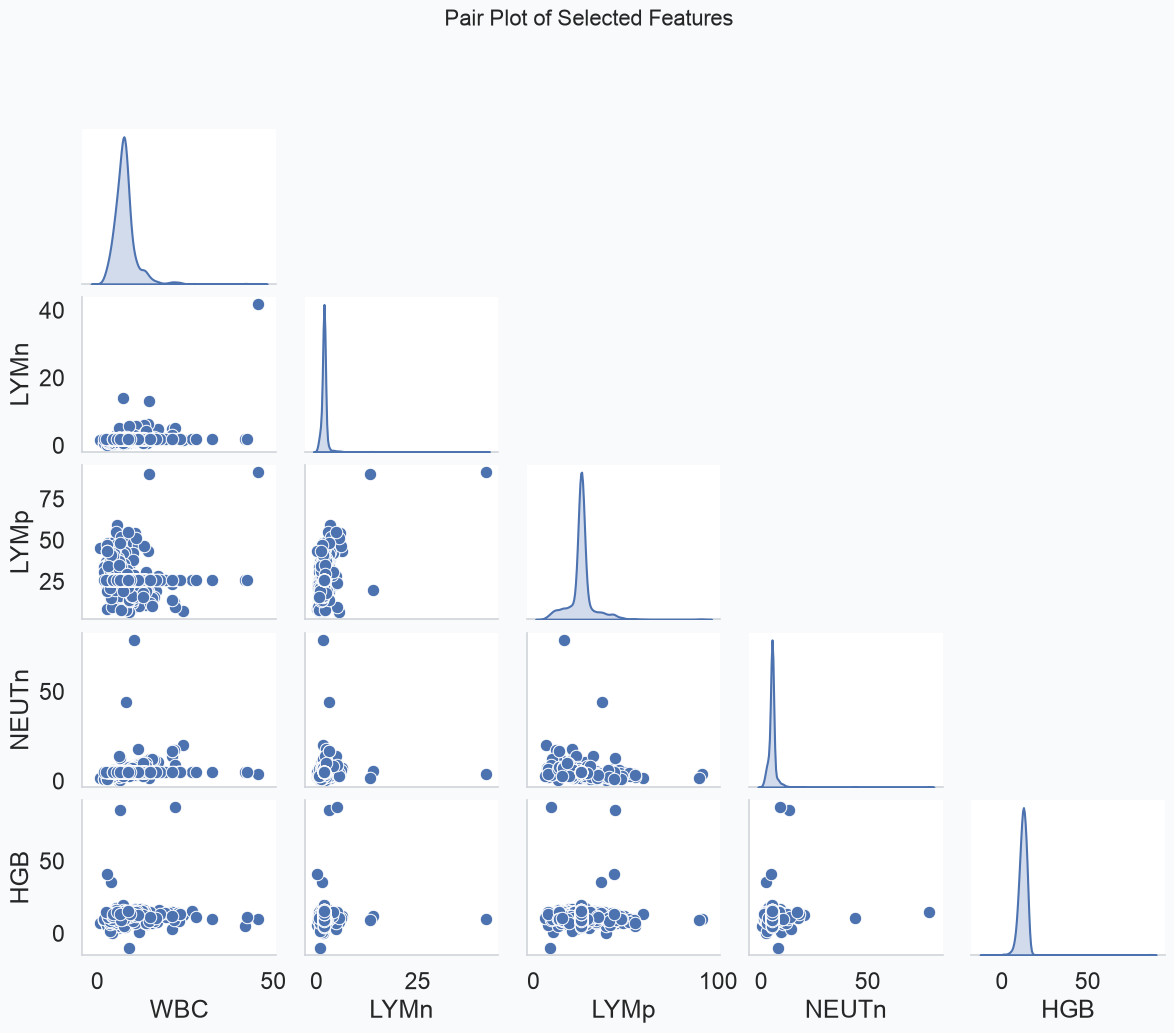

In [13]:
multivariate_analyzer = SimpleMultivariateAnalysis()
numeric_data= df[df.select_dtypes(include= "number").columns]


multivariate_analyzer.analyze(numeric_data)